Сгенерируем три случайные регрессии с помощью функции `make_regression` из `scikit-learn`. Чтобы получить нелинейную зависимость, применим к таргету произвольные нелинейные преобразования. Для генерации разных задач потвикаем параметры функции:
* первая регрессия будет наиболее обусловленной и наименее шумной
* вторую регрессию сделаем наименее обусловленной из трех и чуть более шумной, чем первая
* третья - чуть хуже обусловлена, чем вторая, но самая шумная

In [181]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

seed = 23
n_samples = 1000
n_features = 100
n_output = 1

X1, y1 = make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_targets=n_output,
    noise=1,
    effective_rank=2,
    random_state=seed
)
y1 = np.sin(y1) * 3 + 13

X2, y2 = make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_targets=n_output,
    noise=5,
    effective_rank=10,
    random_state=seed
)
y2 = np.sqrt(np.abs(y2) + 1e-5) * 0.1 - 7

X3, y3 = make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_targets=n_output,
    noise=10,
    effective_rank=6,
    random_state=seed
)
y3 = np.tan(y3) * (-0.3) + 4

X1.shape, y1.shape

((1000, 100), (1000,))

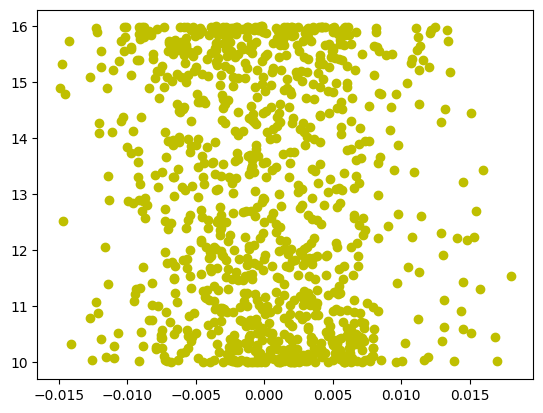

In [182]:
plt.scatter(X1[:, 0], y1, c='y')
plt.show()

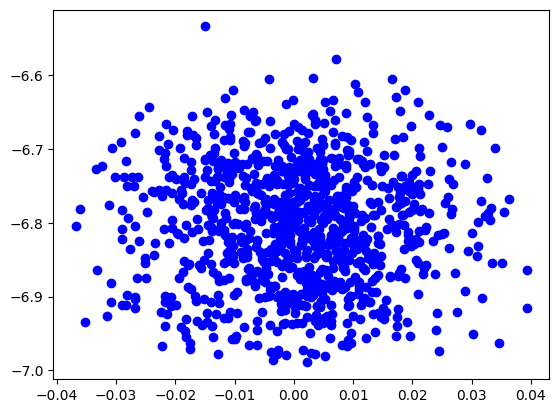

In [183]:
plt.scatter(X2[:, 0], y2, c='b')
plt.show()

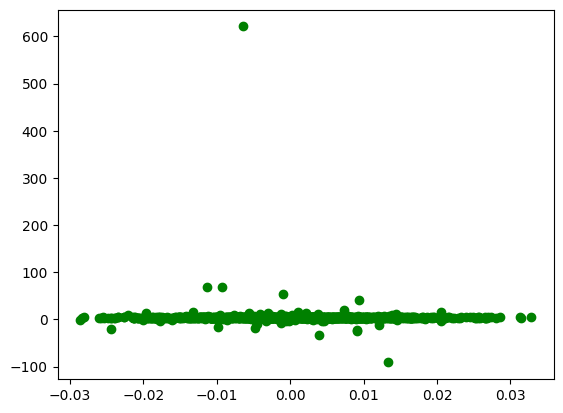

In [184]:
plt.scatter(X3[:, 0], y3, c='g')
plt.show()

Теперь напишем сеть: она будет состоять из двух слоев, каждый из которых будет проинициализирован весами по Ге. Между слоями добавим функцию активации. Также пропишем в конструкторе параметры для опционального включения дропаута и батчнорма.

In [185]:
import torch
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        m.bias.data.fill_(0.01)

class Net(nn.Module):
    def __init__(
            self,
            input_size,
            hidden_size,
            output_size,
            use_dropout=False,
            use_batch_norm=False
    ):
        super(Net, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            *[nn.Dropout(p=0.5) for _ in range(use_dropout)],
            nn.ReLU(),
            *[nn.BatchNorm1d(hidden_size) for _ in range(use_batch_norm)],
            nn.Linear(hidden_size, output_size),
            *[nn.Dropout(p=0.5) for _ in range(use_dropout)]
        )
        self.layers.apply(init_weights)

    def forward(self, x):
        return self.layers(x)

n_hidden = 300

def net_with_batch_norm():
    return Net(n_features, n_hidden, n_output, use_batch_norm=True).to(device)

def net_with_dropout():
    return Net(n_features, n_hidden, n_output, use_dropout=True).to(device)

def net_with_both():
    return Net(n_features, n_hidden, n_output, use_dropout=True, use_batch_norm=True).to(device)

def net():
    return Net(n_features, n_hidden, n_output).to(device)

print(net_with_batch_norm())
print(net_with_dropout())
print(net_with_both())
print(net())

Net(
  (layers): Sequential(
    (0): Linear(in_features=100, out_features=300, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=300, out_features=1, bias=True)
  )
)
Net(
  (layers): Sequential(
    (0): Linear(in_features=100, out_features=300, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=1, bias=True)
    (4): Dropout(p=0.5, inplace=False)
  )
)
Net(
  (layers): Sequential(
    (0): Linear(in_features=100, out_features=300, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Linear(in_features=300, out_features=1, bias=True)
    (5): Dropout(p=0.5, inplace=False)
  )
)
Net(
  (layers): Sequential(
    (0): Linear(in_features=100, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_f

Добавим функцию тестирования сети на данной регрессии и размере батча. Запустим сеть с батчевой нормализацией на первой задаче.

100%|██████████| 20/20 [00:01<00:00, 11.73it/s]


Test error for batch_size=16: 3.302903


100%|██████████| 20/20 [00:00<00:00, 42.15it/s]


Test error for batch_size=64: 3.823814


100%|██████████| 20/20 [00:00<00:00, 103.76it/s]


Test error for batch_size=256: 5.0189834


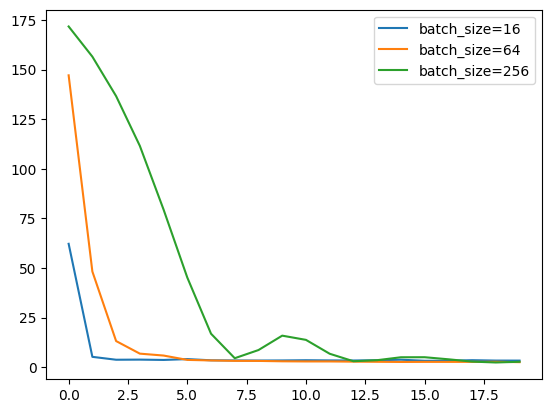

In [186]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch import optim
from tqdm import tqdm

epochs = 20

def run_regression(X, y, batch_size, net, label=None):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
    X_test = torch.tensor(X_test, dtype=torch.float32, device=device)
    y_train = torch.tensor(y_train, dtype=torch.float32, device=device)
    y_test = torch.tensor(y_test, dtype=torch.float32, device=device)

    data_train = list(zip(X_train, y_train))
    data_test = list(zip(X_test, y_test))

    train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(net.parameters(), lr=1e-2, weight_decay=1e-5)
    net.train()

    total_loss = []

    for _ in tqdm(range(epochs)):
        loss_over_epoch = []

        for i, batch in enumerate(train_loader):
            data, labels = batch
            data = data.to(device)
            labels = labels.to(device)
            labels = labels.unsqueeze(1)

            optimizer.zero_grad()

            pred = net(data)
            loss = criterion(pred, labels)
            loss.backward()
            loss_over_epoch.append(loss.detach().cpu())

            optimizer.step()

        total_loss.append(np.mean(loss_over_epoch))

    if label is None:
        plt.plot(total_loss, label=f"batch_size={batch_size}")
    else:
        plt.plot(total_loss, label=label)

    net.eval()
    errors = []

    with torch.no_grad():
        for batch in test_loader:
            data, labels = batch
            data = data.to(device)
            labels = labels.to(device)
            labels = labels.unsqueeze(1)

            pred = net(data)
            error = criterion(pred, labels)
            errors.append(error.detach().cpu())

    if label is None:
        print(f"Test error for batch_size={batch_size}:", np.mean(errors))
    else:
        print(f"Test error {label}:", np.mean(errors))

run_regression(X1, y1, batch_size=16, net=net_with_batch_norm())
run_regression(X1, y1, batch_size=64, net=net_with_batch_norm())
run_regression(X1, y1, batch_size=256, net=net_with_batch_norm())
plt.legend()
plt.show()

Для первой регрессии лучшим размером батча оказывается самый малый - 16. Сеть быстрее всего сходится и выдает лучший результат на тестовом множестве.

100%|██████████| 20/20 [00:01<00:00, 12.37it/s]


Test error for batch_size=16: 0.017580852


100%|██████████| 20/20 [00:00<00:00, 41.08it/s]


Test error for batch_size=64: 0.030264879


100%|██████████| 20/20 [00:00<00:00, 100.18it/s]


Test error for batch_size=256: 0.109540164


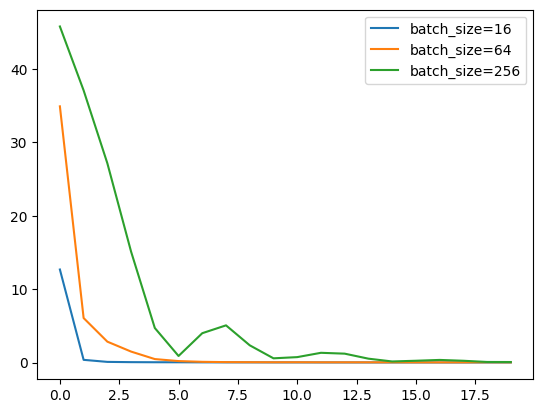

In [187]:
run_regression(X2, y2, batch_size=16, net=net_with_batch_norm())
run_regression(X2, y2, batch_size=64, net=net_with_batch_norm())
run_regression(X2, y2, batch_size=256, net=net_with_batch_norm())
plt.legend()
plt.show()

Опять же, лучший результат на тестовом множестве показывает минимальный размер батча, однако результаты сети с батчем 256 немногим хуже.

100%|██████████| 20/20 [00:01<00:00, 12.37it/s]


Test error for batch_size=16: 62.854107


100%|██████████| 20/20 [00:00<00:00, 46.93it/s]


Test error for batch_size=64: 199.27219


100%|██████████| 20/20 [00:00<00:00, 101.18it/s]


Test error for batch_size=256: 8.860448


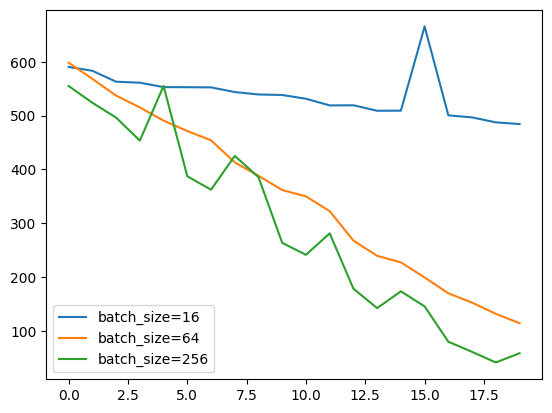

In [188]:
run_regression(X3, y3, batch_size=16, net=net_with_batch_norm())
run_regression(X3, y3, batch_size=64, net=net_with_batch_norm())
run_regression(X3, y3, batch_size=256, net=net_with_batch_norm())
plt.legend()
plt.show()

Здесь лосс немного сходит с ума, сходимость явно страдает. Предполагаю, дело в том, что в третьей регрессии достаточно много аутлайеров, с которыми MSE плохо справляется. На этой задаче пальму первенства в близкой борьбе с батчем 16 забирает самый большой батч.

По результатам тестов предпочтение отдается самому маленькому батчу. Теперь запустим модель, включая и выключая слои батчевой нормализации и дропаута.

Посмотрим на то, как отработают сети на тех же регрессиях с этими изменениями.

100%|██████████| 20/20 [00:01<00:00, 16.79it/s]


Test error nothing: 3.34037


100%|██████████| 20/20 [00:01<00:00, 13.43it/s]


Test error with batch norm: 3.7536027


100%|██████████| 20/20 [00:01<00:00, 14.62it/s]


Test error with dropout: 52.622112


100%|██████████| 20/20 [00:01<00:00, 12.61it/s]


Test error with both: 37.60928


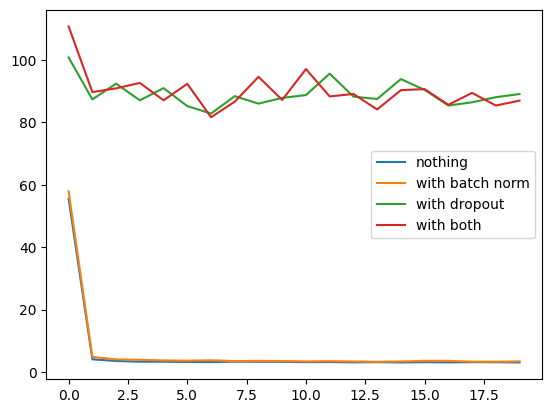

In [189]:
best_batch_size = 16

def run_regression_switching(X, y):
    run_regression(X, y, batch_size=best_batch_size, net=net(), label="nothing")
    run_regression(X, y, batch_size=best_batch_size, net=net_with_batch_norm(), label="with batch norm")
    run_regression(X, y, batch_size=best_batch_size, net=net_with_dropout(), label="with dropout")
    run_regression(X, y, batch_size=best_batch_size, net=net_with_both(), label="with both")
    plt.legend()
    plt.show()

run_regression_switching(X1, y1)

100%|██████████| 20/20 [00:01<00:00, 16.80it/s]


Test error nothing: 0.008630842


100%|██████████| 20/20 [00:01<00:00, 12.50it/s]


Test error with batch norm: 0.0114362165


100%|██████████| 20/20 [00:01<00:00, 14.99it/s]


Test error with dropout: 11.214396


100%|██████████| 20/20 [00:01<00:00, 12.01it/s]


Test error with both: 11.550915


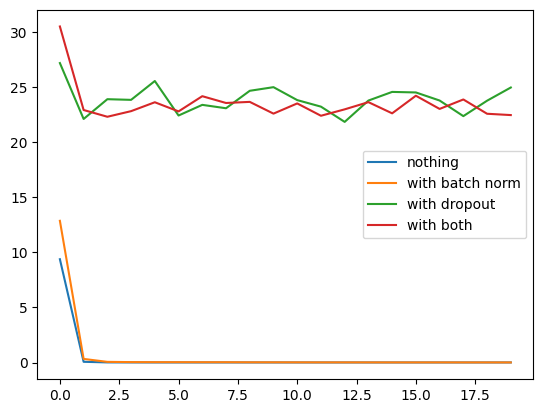

In [190]:
run_regression_switching(X2, y2)

100%|██████████| 20/20 [00:01<00:00, 16.55it/s]


Test error nothing: 25.287527


100%|██████████| 20/20 [00:01<00:00, 15.35it/s]


Test error with batch norm: 65.72821


100%|██████████| 20/20 [00:01<00:00, 15.57it/s]


Test error with dropout: 12.414716


100%|██████████| 20/20 [00:01<00:00, 13.88it/s]


Test error with both: 12.66984


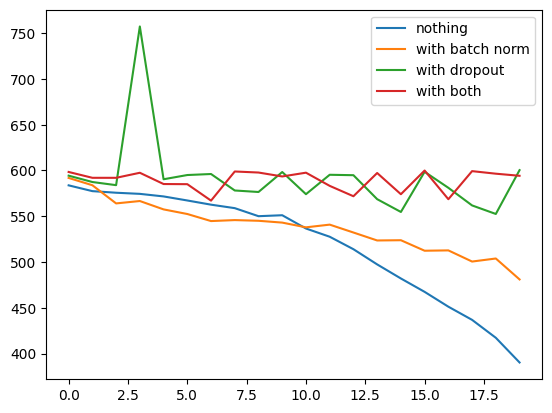

In [191]:
run_regression_switching(X3, y3)

Из данных графиков сложно сделать обобщенный вывод, так как показатели третьей регрессии значительно отличаются от первых двух. На первой задаче сеть с батчевой нормализацией показывает лучшие результаты, на второй - слегка худшие относительно бейзлайна; дропаут заметно ухудшает работу сети в обоих случаях. Объяснение показателей третьей регрессии неочевидно: может быть, те же самые аутлайеры сильно сказываются на подсчете статистик для батчевой нормализации, из-за чего она работает хуже дропаута.

Из данных наблюдений можно сделать следующие выводы:
1. При уменьшении вероятности или удалении одного из слоев дропаута результаты будут лучше, однако нет оснований полагать, что они превзойдут показатели батчевой нормализации.
2. Возможно, дропаут просто плохо работает на регрессии. Причина этого может заключаться в том, что отключение нескольких нейронов на итерации обучения гораздо более критично отразится на предсказании абсолютного значения, нежели относительного - как, например, в случае предсказания вероятности класса.
3. Количество признаков в приведенных задачах регрессии мало (особенно для нейронных сетей) - может быть, на большом количестве признаков сеть с дропаутом будет обучаться лучше за счет того, что в рамках одной итерации будет обучаться больше весов.